# EOD Zootopia - Exploitation des Résultats
## Analyse Comparative Dry / Normal / Wet
---

In [211]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

# Configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Couleurs scénarios
colors = {'dry': '#E74C3C', 'normal': '#3498DB', 'wet': '#27AE60'}

# Charger les résultats
results = {}
for scenario in ['dry', 'normal', 'wet']:
    try:
        results[scenario] = pd.read_csv(f'../results/results_{scenario}.csv')
        print(f"✅ Scénario {scenario.upper()} : {len(results[scenario])} heures chargées")
    except FileNotFoundError:
        print(f"❌ Fichier results_{scenario}.csv non trouvé")

print(f"\nColonnes disponibles : {results['dry'].columns.tolist() if 'dry' in results else 'N/A'}")

✅ Scénario DRY : 8760 heures chargées
✅ Scénario NORMAL : 8760 heures chargées
✅ Scénario WET : 8760 heures chargées

Colonnes disponibles : ['hour', 'month', 'load', 'Phy_fdl', 'Phy_lac', 'P_nuc', 'P_charbon', 'P_ccg', 'P_tac', 'P_cogen', 'P_fioul', 'P_eolien', 'P_solaire', 'P_dechets', 'P_biomasse', 'stock_hydro', 'stock_STEP', 'Puns', 'Pspill', 'UC_nuc', 'UC_charbon', 'UC_ccg', 'UC_tac', 'UC_cogen', 'UC_fioul', 'Pcharge_STEP', 'Pdecharge_STEP', 'stock_hydro_min', 'stock_hydro_max', 'slack_seasonal', 'slack_stock_min', 'slack_stock_max', 'S_socle', 'S_surplus', 'inflows_lac', 'inflows_fdl', 'infeasible_flag']


## 1️⃣ RÉSUMÉ ANNUEL PAR SCÉNARIO

In [212]:
print("="*100)
print("📊 RÉSUMÉ ANNUEL - 3 SCÉNARIOS")
print("="*100)

summary = {}
for scenario in ['dry', 'normal', 'wet']:
    if scenario not in results:
        continue
    
    df = results[scenario]
    
    # Charges et productions
    load_total = df['load'].sum() / 1e6  # TWh
    hydro_lac = df['Phy_lac'].sum() / 1e6
    hydro_fdl = df['Phy_fdl'].sum() / 1e6
    hydro_total = hydro_lac + hydro_fdl
    
    # Thermique
    p_nuc = df['P_nuc'].sum() / 1e6
    p_charbon = df['P_charbon'].sum() / 1e6 if 'P_charbon' in df.columns else 0
    p_gaz = (df['P_ccg'].sum() + df['P_tac'].sum() + df['P_cogen'].sum()) / 1e6 if all(c in df.columns for c in ['P_ccg', 'P_tac', 'P_cogen']) else 0
    
    # ENR et bioénergies
    p_enr = (df['P_eolien'].sum() + df['P_solaire'].sum()) / 1e6 if all(c in df.columns for c in ['P_eolien', 'P_solaire']) else 0
    p_bio = (df['P_dechets'].sum() + df['P_biomasse'].sum()) / 1e6 if all(c in df.columns for c in ['P_dechets', 'P_biomasse']) else 0
    
    # Défaillance et stockage
    puns = df['Puns'].sum() / 1e6 if 'Puns' in df.columns else 0
    pspill = df['Pspill'].sum() / 1e6 if 'Pspill' in df.columns else 0
    step_turb = df['Pdecharge_STEP'].sum() / 1e6 if 'Pdecharge_STEP' in df.columns else 0
    
    # Stocks moyens
    stock_hydro_mean = df['stock_hydro'].mean() / 1e6
    stock_step_mean = df['stock_STEP'].mean() / 1e6 if 'stock_STEP' in df.columns else 0
    
    # Fiabilité
    fiabilite = 100 * (1 - puns / load_total) if load_total > 0 else 100
    
    summary[scenario] = {
        'charge_twh': load_total,
        'hydro_total': hydro_total,
        'hydro_lac': hydro_lac,
        'hydro_fdl': hydro_fdl,
        'p_nuc': p_nuc,
        'p_charbon': p_charbon,
        'p_gaz': p_gaz,
        'p_enr': p_enr,
        'p_bio': p_bio,
        'puns': puns,
        'pspill': pspill,
        'step_turb': step_turb,
        'stock_hydro_mean': stock_hydro_mean,
        'stock_step_mean': stock_step_mean,
        'fiabilite': fiabilite
    }

for scenario in ['dry', 'normal', 'wet']:
    if scenario not in summary:
        continue
    s = summary[scenario]
    
    print(f"\n{scenario.upper():15} | Charge: {s['charge_twh']:6.2f} TWh")
    print("-" * 100)
    print(f"  Hydraulique    | Lacs: {s['hydro_lac']:5.2f} | FDL: {s['hydro_fdl']:5.2f} | Total: {s['hydro_total']:5.2f} TWh ({100*s['hydro_total']/s['charge_twh']:5.1f}%)")
    print(f"  Nucléaire      | {s['p_nuc']:6.2f} TWh ({100*s['p_nuc']/s['charge_twh']:5.1f}%)")
    print(f"  Thermique      | Charbon: {s['p_charbon']:5.2f} | Gaz: {s['p_gaz']:5.2f} | Total: {s['p_charbon']+s['p_gaz']:5.2f} TWh")
    print(f"  ENR            | Éolien+Solaire: {s['p_enr']:5.2f} TWh ({100*s['p_enr']/s['charge_twh']:5.1f}%)")
    print(f"  Bioénergies    | {s['p_bio']:6.2f} TWh")
    print(f"  ---")
    print(f"  Défaillance    | {s['puns']:6.4f} TWh | Fiabilité: {s['fiabilite']:6.2f}%")
    print(f"  Spill hydro    | {s['pspill']:6.4f} TWh")
    print(f"  STEP turbinage | {s['step_turb']:6.2f} TWh")
    print(f"  Stocks moyens  | Hydro: {s['stock_hydro_mean']:5.2f} TWh | STEP: {s['stock_step_mean']:5.2f} TWh")

📊 RÉSUMÉ ANNUEL - 3 SCÉNARIOS

DRY             | Charge:  85.09 TWh
----------------------------------------------------------------------------------------------------
  Hydraulique    | Lacs:  2.82 | FDL:  4.25 | Total:  7.07 TWh (  8.3%)
  Nucléaire      |  48.90 TWh ( 57.5%)
  Thermique      | Charbon:  4.83 | Gaz:  2.03 | Total:  6.86 TWh
  ENR            | Éolien+Solaire: 18.50 TWh ( 21.7%)
  Bioénergies    |   3.72 TWh
  ---
  Défaillance    | 0.0008 TWh | Fiabilité: 100.00%
  Spill hydro    | 0.0000 TWh
  STEP turbinage |   1.89 TWh
  Stocks moyens  | Hydro:  0.51 TWh | STEP:  0.02 TWh

NORMAL          | Charge:  85.09 TWh
----------------------------------------------------------------------------------------------------
  Hydraulique    | Lacs:  4.60 | FDL:  5.31 | Total:  9.91 TWh ( 11.6%)
  Nucléaire      |  46.84 TWh ( 55.0%)
  Thermique      | Charbon:  4.16 | Gaz:  1.88 | Total:  6.04 TWh
  ENR            | Éolien+Solaire: 18.50 TWh ( 21.7%)
  Bioénergies    |   3.72 TWh

## 2️⃣ SUIVI STOCK HYDRAULIQUE + LIMITES

✅ Limites historiques chargées : 365 jours
   Min: 16.0% - 64.0%
   Max: 51.5% - 92.0%


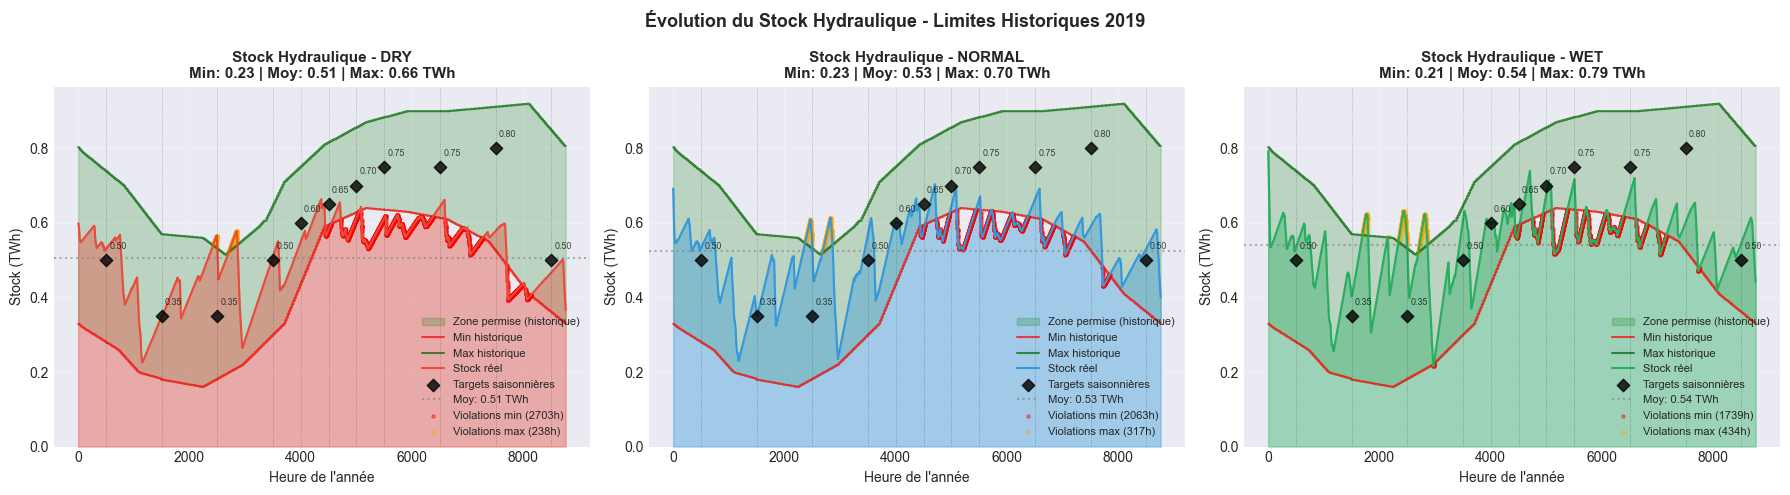


⚠️  VIOLATIONS DES CONTRAINTES DE STOCK

DRY
  Violations MIN :  2703 heures (30.86%)
  Violations MAX :   238 heures (2.72%)
  ❌ MAUVAIS - Violations importantes

NORMAL
  Violations MIN :  2063 heures (23.55%)
  Violations MAX :   317 heures (3.62%)
  ❌ MAUVAIS - Violations importantes

WET
  Violations MIN :  1739 heures (19.85%)
  Violations MAX :   434 heures (4.95%)
  ❌ MAUVAIS - Violations importantes


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from openpyxl import load_workbook

# ===== CHARGER LES LIMITES HISTORIQUES =====
excel_file = '../data/Donnees_etude_de_cas_ETE305.xlsx'

# Charger directement depuis les cellules Excel
wb = load_workbook(excel_file)
ws = wb['Stock hydro']  # Ou le vrai nom de la feuille

lev_low = []
lev_high = []
dates = []

for row in range(4, 369):  # B4:B368 = 365 lignes
    lev_low.append(ws[f'B{row}'].value)
    lev_high.append(ws[f'C{row}'].value)
    dates.append(ws[f'A{row}'].value)

# Convertir en array
lev_low = np.array(lev_low, dtype=float)
lev_high = np.array(lev_high, dtype=float)
dates = np.array(dates)

# Convertir % en TWh (capacité = 1 TWh)
stock_min_histor_daily = (lev_low / 100) * 1.0
stock_max_histor_daily = (lev_high / 100) * 1.0

HYDRO_SHIFT_DAYS = 181

# Recaler les limites journalières (comme recale_hydro_values en Julia)
stock_min_histor_daily = np.roll(stock_min_histor_daily, -HYDRO_SHIFT_DAYS)
stock_max_histor_daily = np.roll(stock_max_histor_daily, -HYDRO_SHIFT_DAYS)

print(f"✅ Limites historiques chargées : {len(lev_low)} jours")
print(f"   Min: {lev_low.min():.1f}% - {lev_low.max():.1f}%")
print(f"   Max: {lev_high.min():.1f}% - {lev_high.max():.1f}%")

# ===== GRAPHIQUES =====
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, scenario in enumerate(['dry', 'normal', 'wet']):
    if scenario not in results:
        continue
    
    df = results[scenario]
    ax = axes[idx]
    
    # Stock réel (horaire) en TWh
    stock = df['stock_hydro'].values / 1e6
    hours = np.arange(len(stock))
    
    # Étendre les limites journalières sur 8760 heures
    # Chaque jour a 24 heures
    stock_min_histor = np.repeat(stock_min_histor_daily, 24)[:len(stock)]
    stock_max_histor = np.repeat(stock_max_histor_daily, 24)[:len(stock)]
    
    # Zone permise (historique)
    ax.fill_between(hours, stock_min_histor, stock_max_histor, alpha=0.2, color='green', label='Zone permise (historique)')
    ax.plot(hours, stock_min_histor, 'r-', linewidth=1.5, alpha=0.7, label='Min historique')
    ax.plot(hours, stock_max_histor, 'darkgreen', linewidth=1.5, alpha=0.7, label='Max historique')
    
    # Stock réel
    ax.fill_between(hours, 0, stock, alpha=0.4, color=colors[scenario])
    ax.plot(hours, stock, color=colors[scenario], linewidth=1.5, label='Stock réel')

    SEASONAL_TARGETS = {
            "target_1": {"hour": 500,  "dry": 0.50, "normal": 0.50, "wet": 0.50},
            "target_2": {"hour": 1500, "dry": 0.35, "normal": 0.35, "wet": 0.35},
            "target_3": {"hour": 2500, "dry": 0.35, "normal": 0.35, "wet": 0.35},
            "target_4": {"hour": 3500, "dry": 0.50, "normal": 0.50, "wet": 0.50},
            "target_45": {"hour": 4000, "dry": 0.60, "normal": 0.60, "wet": 0.60},
            "target_5": {"hour": 4500, "dry": 0.65, "normal": 0.65, "wet": 0.65},
            "target_55": {"hour": 5000, "dry": 0.70, "normal": 0.70, "wet": 0.70},
            "target_6": {"hour": 5500, "dry": 0.80, "normal": 0.80, "wet": 0.80},
            "target_7": {"hour": 6500, "dry": 0.80, "normal": 0.80, "wet": 0.80},
            "target_8": {"hour": 7500, "dry": 0.80, "normal": 0.80, "wet": 0.80},
            "target_9": {"hour": 8500, "dry": 0.50, "normal": 0.50, "wet": 0.50},
        }

    target_hours  = [t["hour"]       for t in SEASONAL_TARGETS.values()]
    target_values = [t[scenario]     for t in SEASONAL_TARGETS.values()]

    ax.scatter(target_hours, target_values,
               color='black', marker='D', s=40, zorder=5,
               label='Targets saisonnières', alpha=0.8)

    for h, v in zip(target_hours, target_values):
        ax.axvline(x=h, color='black', linestyle=':', linewidth=0.6, alpha=0.3)
        ax.annotate(f'{v:.2f}', xy=(h, v), xytext=(h+60, v+0.03),
                    fontsize=6.5, color='black', alpha=0.7)
    
    # Moyenne
    ax.axhline(y=stock.mean(), color='gray', linestyle=':', linewidth=1.5, alpha=0.6, label=f'Moy: {stock.mean():.2f} TWh')
    
    # Violations
    violations_min = stock < stock_min_histor
    violations_max = stock > stock_max_histor
    
    if violations_min.any():
        ax.scatter(hours[violations_min], stock[violations_min], color='red', s=5, alpha=0.4, label=f'Violations min ({violations_min.sum()}h)')
    if violations_max.any():
        ax.scatter(hours[violations_max], stock[violations_max], color='orange', s=5, alpha=0.4, label=f'Violations max ({violations_max.sum()}h)')
    
    ax.set_title(f'Stock Hydraulique - {scenario.upper()}\nMin: {stock.min():.2f} | Moy: {stock.mean():.2f} | Max: {stock.max():.2f} TWh',
                fontweight='bold', fontsize=11)
    ax.set_ylabel('Stock (TWh)', fontsize=10)
    ax.set_xlabel('Heure de l\'année', fontsize=10)
    ax.legend(loc='best', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(bottom=0)

plt.suptitle('Évolution du Stock Hydraulique - Limites Historiques 2019', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ===== RÉSUMÉ VIOLATIONS =====
print("\n" + "="*100)
print("⚠️  VIOLATIONS DES CONTRAINTES DE STOCK")
print("="*100)

for scenario in ['dry', 'normal', 'wet']:
    if scenario not in results:
        continue
    
    df = results[scenario]
    stock = df['stock_hydro'].values / 1e6
    
    stock_min_histor = np.repeat(stock_min_histor_daily, 24)[:len(stock)]
    stock_max_histor = np.repeat(stock_max_histor_daily, 24)[:len(stock)]
    
    violations_min = (stock < stock_min_histor).sum()
    violations_max = (stock > stock_max_histor).sum()
    
    print(f"\n{scenario.upper()}")
    print(f"  Violations MIN : {violations_min:5d} heures ({100*violations_min/len(stock):.2f}%)")
    print(f"  Violations MAX : {violations_max:5d} heures ({100*violations_max/len(stock):.2f}%)")
    
    if violations_min + violations_max == 0:
        print(f"  ✅ EXCELLENT - Contraintes bien respectées")
    elif violations_min + violations_max < 100:
        print(f"  ⚠️  BON - Quelques violations mineures")
    else:
        print(f"  ❌ MAUVAIS - Violations importantes")

## 3️⃣ PRODUCTION HYDRAULIQUE MENSUELLE (Lacs vs FDL)

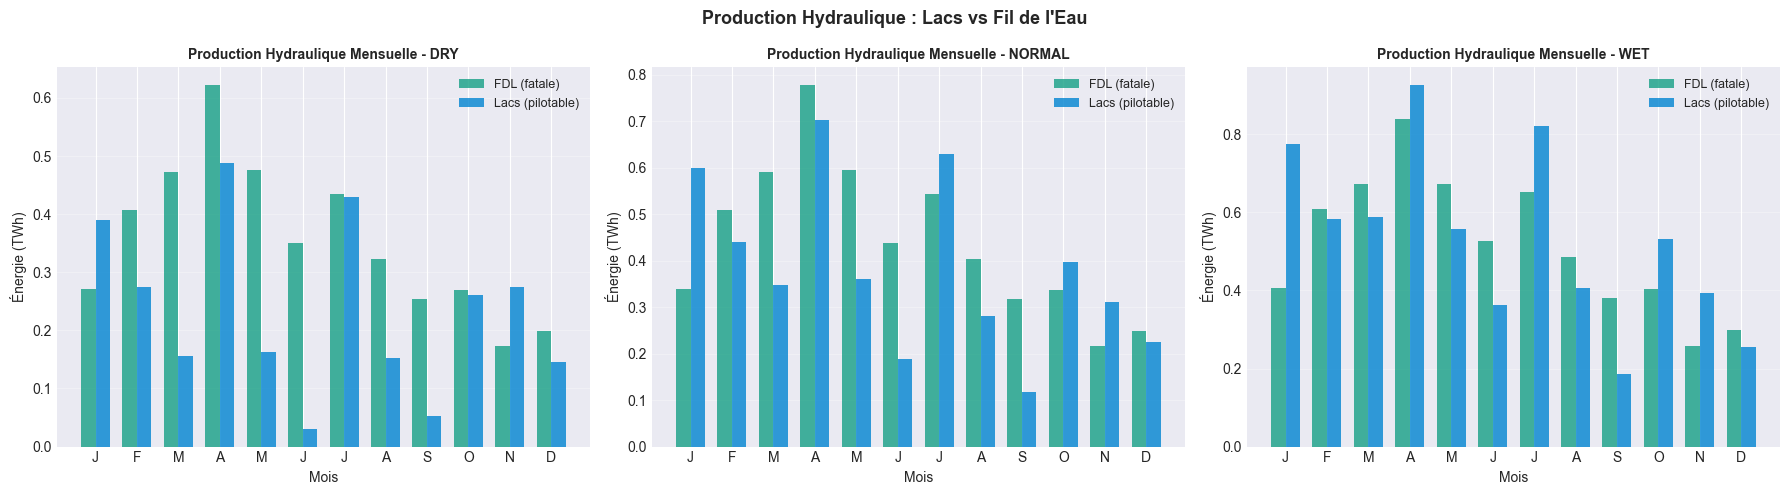

In [214]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, scenario in enumerate(['dry', 'normal', 'wet']):
    if scenario not in results:
        continue
    
    df = results[scenario]
    ax = axes[idx]
    
    # Production mensuelle
    monthly_lac = df.groupby('month')['Phy_lac'].sum() / 1e6
    monthly_fdl = df.groupby('month')['Phy_fdl'].sum() / 1e6
    
    x = np.arange(1, 13)
    width = 0.35
    
    ax.bar(x - width/2, monthly_fdl.reindex(x, fill_value=0), width, label='FDL (fatale)', color='#16A085', alpha=0.8)
    ax.bar(x + width/2, monthly_lac.reindex(x, fill_value=0), width, label='Lacs (pilotable)', color='#0084D1', alpha=0.8)
    
    ax.set_title(f'Production Hydraulique Mensuelle - {scenario.upper()}', fontweight='bold', fontsize=10)
    ax.set_ylabel('Énergie (TWh)', fontsize=10)
    ax.set_xlabel('Mois', fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels(['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D'])
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Production Hydraulique : Lacs vs Fil de l\'Eau', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4️⃣ MIX ÉNERGÉTIQUE ANNUEL

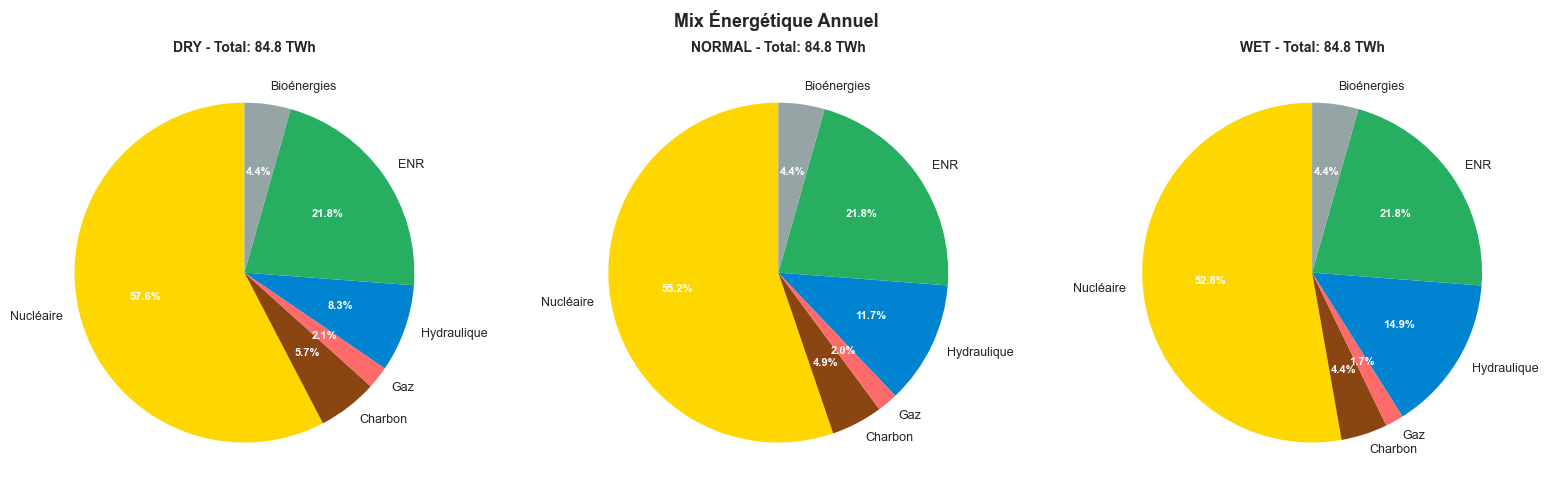

In [215]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, scenario in enumerate(['dry', 'normal', 'wet']):
    if scenario not in results:
        continue
    
    df = results[scenario]
    ax = axes[idx]
    
    # Production par source
    p_nuc = df['P_nuc'].sum() / 1e6 if 'P_nuc' in df.columns else 0
    p_charbon = df['P_charbon'].sum() / 1e6 if 'P_charbon' in df.columns else 0
    p_ccg = df['P_ccg'].sum() / 1e6 if 'P_ccg' in df.columns else 0
    p_tac = df['P_tac'].sum() / 1e6 if 'P_tac' in df.columns else 0
    p_gaz = p_ccg + p_tac
    p_hydro = df['Phy_lac'].sum() / 1e6 + df['Phy_fdl'].sum() / 1e6 if all(c in df.columns for c in ['Phy_lac', 'Phy_fdl']) else 0
    p_eolien = df['P_eolien'].sum() / 1e6 if 'P_eolien' in df.columns else 0
    p_solaire = df['P_solaire'].sum() / 1e6 if 'P_solaire' in df.columns else 0
    p_bio = (df['P_dechets'].sum() + df['P_biomasse'].sum()) / 1e6 if all(c in df.columns for c in ['P_dechets', 'P_biomasse']) else 0
    
    productions = [p_nuc, p_charbon, p_gaz, p_hydro, p_eolien + p_solaire, p_bio]
    labels = ['Nucléaire', 'Charbon', 'Gaz', 'Hydraulique', 'ENR', 'Bioénergies']
    colors_pie = ['#FFD700', '#8B4513', '#FF6B6B', '#0084D1', '#27AE60', '#95A5A6']
    
    # Créer le pie chart
    wedges, texts, autotexts = ax.pie(
        productions, 
        labels=labels, 
        autopct='%1.1f%%',
        colors=colors_pie,
        startangle=90,
        textprops={'fontsize': 9}
    )
    
    # Mettre en gras les pourcentages
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
        autotext.set_fontsize(8)
    
    total = sum(productions)
    ax.set_title(f'{scenario.upper()} - Total: {total:.1f} TWh', fontweight='bold', fontsize=10)

plt.suptitle('Mix Énergétique Annuel', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5️⃣ VIOLATIONS STOCK (Slack Min/Max)

In [216]:
print("\n" + "="*100)
print("⚠️  VIOLATIONS DES CONTRAINTES DE STOCK HYDRAULIQUE")
print("="*100)

for scenario in ['dry', 'normal', 'wet']:
    if scenario not in results:
        continue
    
    df = results[scenario]
    
    if 'slack_stock_min' not in df.columns or 'slack_stock_max' not in df.columns:
        print(f"\n{scenario.upper()} : Colonnes slack non disponibles")
        continue
    
    # Heures avec violations
    hours_slack_min = (df['slack_stock_min'] > 0).sum()
    hours_slack_max = (df['slack_stock_max'] > 0).sum()
    
    total_slack_min = df['slack_stock_min'].sum() / 1e6
    total_slack_max = df['slack_stock_max'].sum() / 1e6
    
    print(f"\n{scenario.upper()}")
    print("-" * 100)
    print(f"  Slack MIN (stock trop bas)      : {hours_slack_min:4d} heures | Total: {total_slack_min:8.4f} TWh")
    print(f"  Slack MAX (stock trop haut)     : {hours_slack_max:4d} heures | Total: {total_slack_max:8.4f} TWh")
    print(f"  TOTAL violations stock          : {total_slack_min + total_slack_max:8.4f} TWh")
    
    if total_slack_min + total_slack_max < 0.001:
        print(f"  ✅ EXCELLENT - Contraintes stock bien respectées")
    elif total_slack_min + total_slack_max < 0.01:
        print(f"  ⚠️  BON - Quelques violations mineures")
    else:
        print(f"  ❌ MAUVAIS - Violations importantes")


⚠️  VIOLATIONS DES CONTRAINTES DE STOCK HYDRAULIQUE

DRY
----------------------------------------------------------------------------------------------------
  Slack MIN (stock trop bas)      : 2968 heures | Total: 317.9325 TWh
  Slack MAX (stock trop haut)     :  451 heures | Total:  12.0108 TWh
  TOTAL violations stock          : 329.9434 TWh
  ❌ MAUVAIS - Violations importantes

NORMAL
----------------------------------------------------------------------------------------------------
  Slack MIN (stock trop bas)      : 2430 heures | Total: 221.6438 TWh
  Slack MAX (stock trop haut)     :  409 heures | Total:  10.2033 TWh
  TOTAL violations stock          : 231.8471 TWh
  ❌ MAUVAIS - Violations importantes

WET
----------------------------------------------------------------------------------------------------
  Slack MIN (stock trop bas)      : 1938 heures | Total: 143.0245 TWh
  Slack MAX (stock trop haut)     :  352 heures | Total:   8.0473 TWh
  TOTAL violations stock          

## 6️⃣ UTILISATION STEP

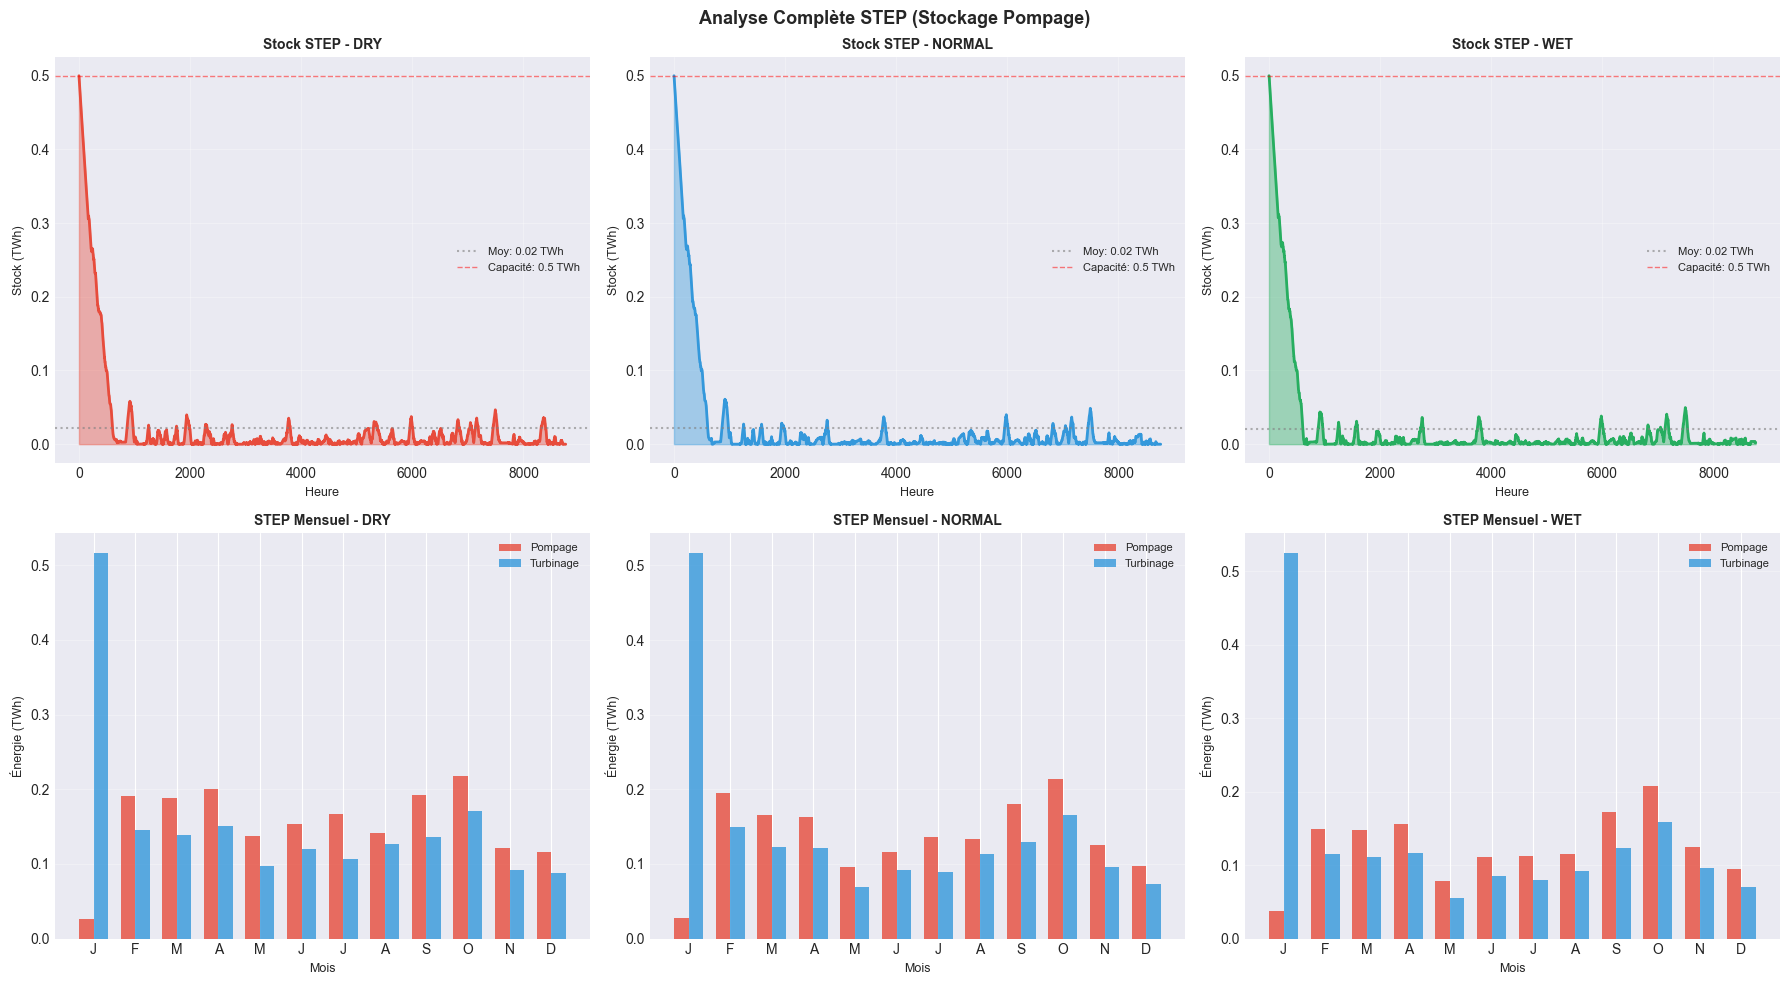


📊 RÉSUMÉ UTILISATION STEP

DRY
  Pompage total    :   1.85 TWh
  Turbinage total  :   1.89 TWh
  Stock moyen      :   0.02 TWh
  Efficacité       : 102.0% (rendement 75%)

NORMAL
  Pompage total    :   1.65 TWh
  Turbinage total  :   1.74 TWh
  Stock moyen      :   0.02 TWh
  Efficacité       : 105.3% (rendement 75%)

WET
  Pompage total    :   1.51 TWh
  Turbinage total  :   1.63 TWh
  Stock moyen      :   0.02 TWh
  Efficacité       : 108.1% (rendement 75%)


In [217]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for idx, scenario in enumerate(['dry', 'normal', 'wet']):
    if scenario not in results:
        continue
    
    df = results[scenario]
    
    # ===== Stock STEP =====
    ax = axes[0, idx]
    
    if 'stock_STEP' in df.columns:
        stock_step = df['stock_STEP'].values / 1e6
        hours = np.arange(len(stock_step))
        
        ax.fill_between(hours, 0, stock_step, alpha=0.4, color=colors[scenario])
        ax.plot(hours, stock_step, color=colors[scenario], linewidth=2)
        ax.axhline(y=stock_step.mean(), color='gray', linestyle=':', linewidth=1.5, alpha=0.6, label=f'Moy: {stock_step.mean():.2f} TWh')
        ax.axhline(y=0.5, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Capacité: 0.5 TWh')
        
        ax.set_title(f'Stock STEP - {scenario.upper()}', fontweight='bold', fontsize=10)
        ax.set_ylabel('Stock (TWh)', fontsize=9)
        ax.set_xlabel('Heure', fontsize=9)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    else:
        ax.text(0.5, 0.5, 'Colonne STEP non disponible', ha='center', va='center', transform=ax.transAxes)
    
    # ===== Pompage/Turbinage STEP mensuel =====
    ax = axes[1, idx]
    
    if 'Pcharge_STEP' in df.columns and 'Pdecharge_STEP' in df.columns:
        monthly_pump = df.groupby('month')['Pcharge_STEP'].sum() / 1e6
        monthly_turb = df.groupby('month')['Pdecharge_STEP'].sum() / 1e6
        
        x = np.arange(1, 13)
        width = 0.35
        
        ax.bar(x - width/2, monthly_pump.reindex(x, fill_value=0), width, label='Pompage', color='#E74C3C', alpha=0.8)
        ax.bar(x + width/2, monthly_turb.reindex(x, fill_value=0), width, label='Turbinage', color='#3498DB', alpha=0.8)
        
        ax.set_title(f'STEP Mensuel - {scenario.upper()}', fontweight='bold', fontsize=10)
        ax.set_ylabel('Énergie (TWh)', fontsize=9)
        ax.set_xlabel('Mois', fontsize=9)
        ax.set_xticks(x)
        ax.set_xticklabels(['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D'])
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3, axis='y')
    else:
        ax.text(0.5, 0.5, 'Colonnes STEP non disponibles', ha='center', va='center', transform=ax.transAxes)

plt.suptitle('Analyse Complète STEP (Stockage Pompage)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Résumé STEP
print("\n" + "="*100)
print("📊 RÉSUMÉ UTILISATION STEP")
print("="*100)
for scenario in ['dry', 'normal', 'wet']:
    if scenario not in results:
        continue
    df = results[scenario]
    
    pump_total = df['Pcharge_STEP'].sum() / 1e6 if 'Pcharge_STEP' in df.columns else 0
    turb_total = df['Pdecharge_STEP'].sum() / 1e6 if 'Pdecharge_STEP' in df.columns else 0
    stock_mean = df['stock_STEP'].mean() / 1e6 if 'stock_STEP' in df.columns else 0
    
    print(f"\n{scenario.upper()}")
    print(f"  Pompage total    : {pump_total:6.2f} TWh")
    print(f"  Turbinage total  : {turb_total:6.2f} TWh")
    print(f"  Stock moyen      : {stock_mean:6.2f} TWh")
    print(f"  Efficacité       : {100*turb_total/pump_total:.1f}% (rendement 75%)" if pump_total > 0 else "  Pas d'utilisation STEP")

## 7️⃣ FIABILITÉ ET DÉFAILLANCES


🚨 DÉFAILLANCES ÉLECTRIQUES (Puns)

DRY
  Défaillance totale   : 0.0008 TWh
  Heures défaillance   :    3 heures
  Fiabilité            : 100.00%
  ✅ Excellent

NORMAL
  Défaillance totale   : 0.0063 TWh
  Heures défaillance   :   12 heures
  Fiabilité            :  99.99%
  ✅ Excellent

WET
  Défaillance totale   : 0.0138 TWh
  Heures défaillance   :   22 heures
  Fiabilité            :  99.98%
  ⚠️  Acceptable


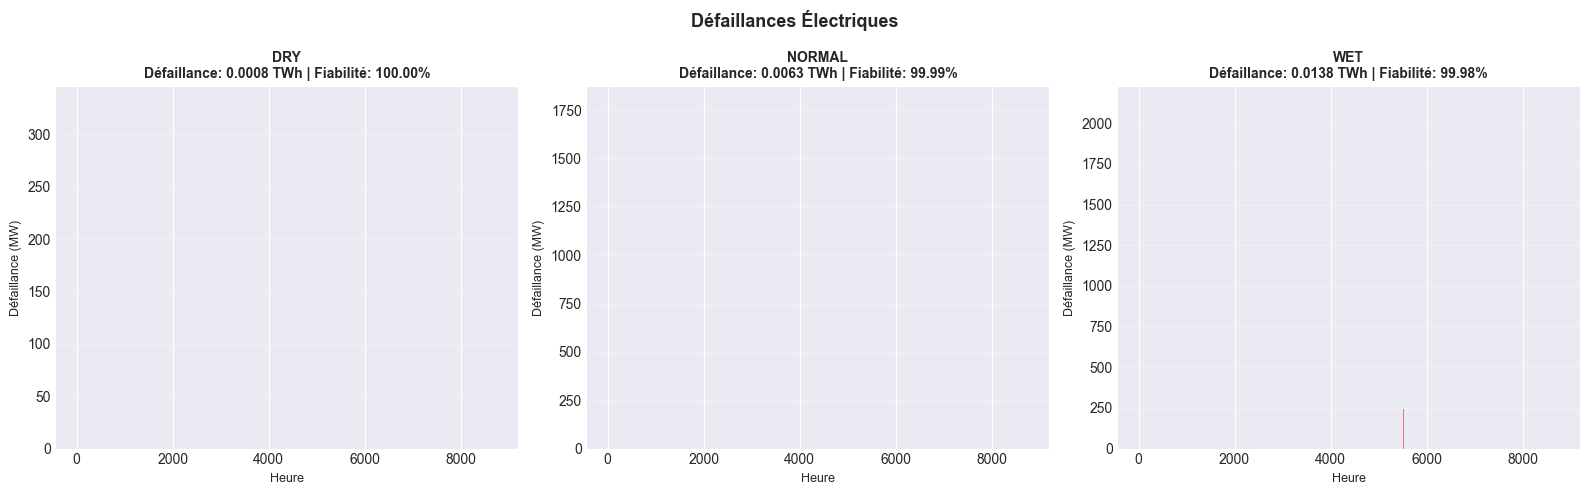

In [218]:
print("\n" + "="*100)
print("🚨 DÉFAILLANCES ÉLECTRIQUES (Puns)")
print("="*100)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, scenario in enumerate(['dry', 'normal', 'wet']):
    if scenario not in results:
        continue
    
    df = results[scenario]
    ax = axes[idx]
    
    if 'Puns' not in df.columns:
        ax.text(0.5, 0.5, 'Colonne Puns non disponible', ha='center', va='center', transform=ax.transAxes)
        continue
    
    puns = df['Puns'].values
    puns_twh = puns.sum() / 1e6
    hours_defaillance = (puns > 0).sum()
    charge_total = df['load'].sum() / 1e6
    fiabilite = 100 * (1 - puns_twh / charge_total)
    
    # Graphique
    hours = np.arange(len(puns))
    ax.bar(hours, puns, width=1, color='#E74C3C', alpha=0.7)
    
    ax.set_title(f'{scenario.upper()}\nDéfaillance: {puns_twh:.4f} TWh | Fiabilité: {fiabilite:.2f}%',
                fontweight='bold', fontsize=10)
    ax.set_ylabel('Défaillance (MW)', fontsize=9)
    ax.set_xlabel('Heure', fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Détails
    print(f"\n{scenario.upper()}")
    print(f"  Défaillance totale   : {puns_twh:.4f} TWh")
    print(f"  Heures défaillance   : {hours_defaillance:4d} heures")
    print(f"  Fiabilité            : {fiabilite:6.2f}%")
    if fiabilite >= 99.99:
        print(f"  ✅ Excellent")
    elif fiabilite >= 99:
        print(f"  ⚠️  Acceptable")
    else:
        print(f"  ❌ À améliorer")

plt.suptitle('Défaillances Électriques', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 8️⃣ ENGAGEMENTS UNITÉS THERMIQUES

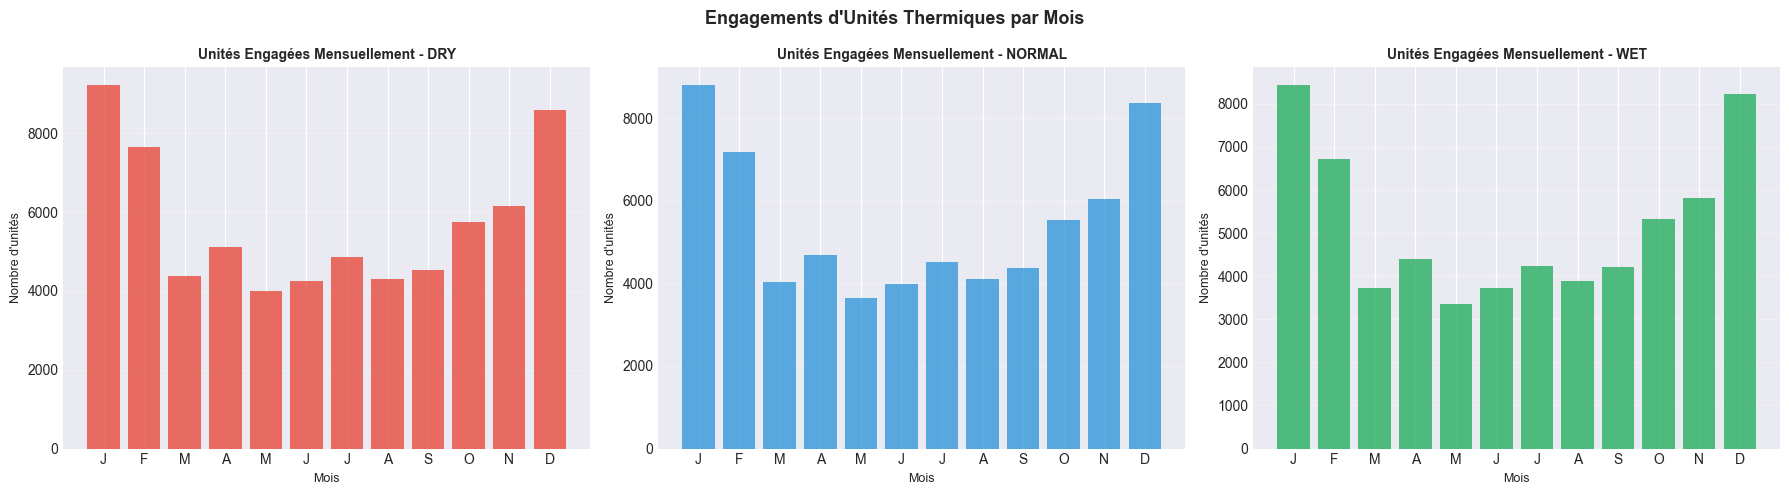

In [219]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, scenario in enumerate(['dry', 'normal', 'wet']):
    if scenario not in results:
        continue
    
    df = results[scenario]
    ax = axes[idx]
    
    # Nombre d'unités engagées
    uc_columns = [c for c in df.columns if c.startswith('UC_')]
    
    if not uc_columns:
        ax.text(0.5, 0.5, 'Colonnes UC non disponibles', ha='center', va='center', transform=ax.transAxes)
        continue
    
    total_uc = sum(df[col] for col in uc_columns if col in df.columns)
    total_uc_monthly = df.groupby('month')[uc_columns].sum().sum(axis=1) if uc_columns else None
    
    if total_uc_monthly is not None:
        x = np.arange(1, 13)
        ax.bar(x, total_uc_monthly.reindex(x, fill_value=0), color=colors[scenario], alpha=0.8)
        
        ax.set_title(f'Unités Engagées Mensuellement - {scenario.upper()}', fontweight='bold', fontsize=10)
        ax.set_ylabel('Nombre d\'unités', fontsize=9)
        ax.set_xlabel('Mois', fontsize=9)
        ax.set_xticks(x)
        ax.set_xticklabels(['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D'])
        ax.grid(True, alpha=0.3, axis='y')
    else:
        ax.text(0.5, 0.5, 'Pas d\'engagements', ha='center', va='center', transform=ax.transAxes)

plt.suptitle('Engagements d\'Unités Thermiques par Mois', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 9️⃣ COMPARAISON APPORTS vs PRODUCTION HYDRAULIQUE

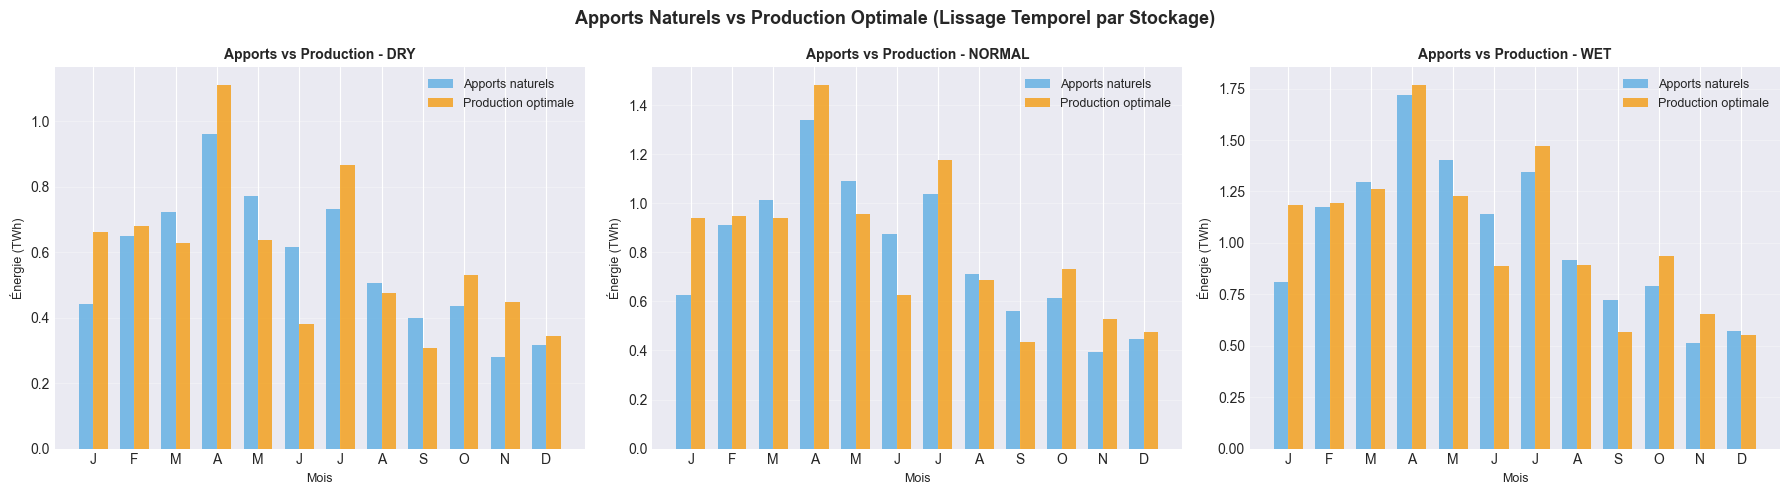

In [220]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, scenario in enumerate(['dry', 'normal', 'wet']):
    if scenario not in results:
        continue
    
    df = results[scenario]
    ax = axes[idx]
    
    if 'inflows_lac' not in df.columns or 'inflows_fdl' not in df.columns:
        ax.text(0.5, 0.5, 'Colonnes inflows non disponibles', ha='center', va='center', transform=ax.transAxes)
        continue
    
    # Apports et productions mensuels
    monthly_inflows = (df.groupby('month')['inflows_lac'].sum() + df.groupby('month')['inflows_fdl'].sum()) / 1e6
    monthly_production = (df.groupby('month')['Phy_lac'].sum() + df.groupby('month')['Phy_fdl'].sum()) / 1e6
    
    x = np.arange(1, 13)
    width = 0.35
    
    ax.bar(x - width/2, monthly_inflows.reindex(x, fill_value=0), width, label='Apports naturels', color='#5DADE2', alpha=0.8)
    ax.bar(x + width/2, monthly_production.reindex(x, fill_value=0), width, label='Production optimale', color='#F39C12', alpha=0.8)
    
    ax.set_title(f'Apports vs Production - {scenario.upper()}', fontweight='bold', fontsize=10)
    ax.set_ylabel('Énergie (TWh)', fontsize=9)
    ax.set_xlabel('Mois', fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels(['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D'])
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Apports Naturels vs Production Optimale (Lissage Temporel par Stockage)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 🔟 RÉSUMÉ COMPARATIF FINAL

In [221]:
print("\n" + "="*100)
print("📊 RÉSUMÉ COMPARATIF - DRY vs NORMAL vs WET")
print("="*100)

# Créer tableau comparatif
comparison = pd.DataFrame({
    'DRY': [
        f"{summary['dry']['charge_twh']:.2f} TWh" if 'dry' in summary else 'N/A',
        f"{summary['dry']['hydro_total']:.2f} TWh ({100*summary['dry']['hydro_total']/summary['dry']['charge_twh']:.1f}%)" if 'dry' in summary else 'N/A',
        f"{summary['dry']['puns']:.4f} TWh" if 'dry' in summary else 'N/A',
        f"{summary['dry']['fiabilite']:.2f}%" if 'dry' in summary else 'N/A',
        f"{summary['dry']['stock_hydro_mean']:.2f} TWh" if 'dry' in summary else 'N/A',
        f"{summary['dry']['step_turb']:.2f} TWh" if 'dry' in summary else 'N/A',
    ],
    'NORMAL': [
        f"{summary['normal']['charge_twh']:.2f} TWh" if 'normal' in summary else 'N/A',
        f"{summary['normal']['hydro_total']:.2f} TWh ({100*summary['normal']['hydro_total']/summary['normal']['charge_twh']:.1f}%)" if 'normal' in summary else 'N/A',
        f"{summary['normal']['puns']:.4f} TWh" if 'normal' in summary else 'N/A',
        f"{summary['normal']['fiabilite']:.2f}%" if 'normal' in summary else 'N/A',
        f"{summary['normal']['stock_hydro_mean']:.2f} TWh" if 'normal' in summary else 'N/A',
        f"{summary['normal']['step_turb']:.2f} TWh" if 'normal' in summary else 'N/A',
    ],
    'WET': [
        f"{summary['wet']['charge_twh']:.2f} TWh" if 'wet' in summary else 'N/A',
        f"{summary['wet']['hydro_total']:.2f} TWh ({100*summary['wet']['hydro_total']/summary['wet']['charge_twh']:.1f}%)" if 'wet' in summary else 'N/A',
        f"{summary['wet']['puns']:.4f} TWh" if 'wet' in summary else 'N/A',
        f"{summary['wet']['fiabilite']:.2f}%" if 'wet' in summary else 'N/A',
        f"{summary['wet']['stock_hydro_mean']:.2f} TWh" if 'wet' in summary else 'N/A',
        f"{summary['wet']['step_turb']:.2f} TWh" if 'wet' in summary else 'N/A',
    ]
}, index=['Charge totale', 'Production hydraulique', 'Défaillance', 'Fiabilité', 'Stock hydro moy', 'STEP turbinage'])

print("\n" + comparison.to_string())
print("\n" + "="*100)


📊 RÉSUMÉ COMPARATIF - DRY vs NORMAL vs WET

                                    DRY            NORMAL                WET
Charge totale                 85.09 TWh         85.09 TWh          85.09 TWh
Production hydraulique  7.07 TWh (8.3%)  9.91 TWh (11.6%)  12.59 TWh (14.8%)
Défaillance                  0.0008 TWh        0.0063 TWh         0.0138 TWh
Fiabilité                       100.00%            99.99%             99.98%
Stock hydro moy                0.51 TWh          0.53 TWh           0.54 TWh
STEP turbinage                 1.89 TWh          1.74 TWh           1.63 TWh



## 🆕 NOUVELLES VARIABLES À EXPORTER DEPUIS JULIA

> Ajouter ces lignes dans le `Dict` de résultats dans `solve_year_rolling` :
>
> ```julia
> "water_price"    => water_price_from_stock(stock_hydro_v[t]),
> "cost_nuc"       => sum(unites[u].prix_marche * P_nuc_v[t, u] for u in nuclear_units),
> "cost_charbon"   => sum(unites[u].prix_marche * P_charbon_v[t, u] for u in charbon_units),
> "cost_ccg"       => sum(unites[u].prix_marche * P_ccg_v[t, u] for u in ccg_units),
> "cost_tac"       => sum(unites[u].prix_marche * P_tac_v[t, u] for u in tac_units),
> "cost_fioul"     => sum(unites[u].prix_marche * P_fioul_v[t, u] for u in fioul_units),
> "Pspill"         => Pspill_v[t],
> ```

## 1️⃣1️⃣ PRIX DE L'EAU DYNAMIQUE

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
months_labels = ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Jun', 'Jul', 'Aoû', 'Sep', 'Oct', 'Nov', 'Déc']

for idx, scenario in enumerate(['dry', 'normal', 'wet']):
    if scenario not in results or 'water_price' not in results[scenario].columns:
        continue
    df = results[scenario]
    ax = axes[idx]

    hours = np.arange(len(df))
    wp = df['water_price'].values
    stock = df['stock_hydro'].values / 1e6

    ax2 = ax.twinx()
    ax2.fill_between(hours, 0, stock, alpha=0.15, color='steelblue')
    ax2.set_ylabel('Stock hydro (TWh)', fontsize=9, color='steelblue')
    ax2.tick_params(axis='y', labelcolor='steelblue')

    ax.plot(hours, wp, color=colors[scenario], linewidth=1.2, alpha=0.9)
    ax.set_title(f'Prix de l\'eau - {scenario.upper()}\nMoy: {wp.mean():.1f} | Min: {wp.min():.1f} | Max: {wp.max():.1f} €/MWh',
                 fontweight='bold', fontsize=10)
    ax.set_ylabel('Prix eau (€/MWh)', fontsize=9)
    ax.set_xlabel('Heure de l\'année', fontsize=9)

    # Repères mensuels
    month_hours = [0, 744, 1416, 2160, 2880, 3624, 4344, 5088, 5832, 6552, 7296, 8016, 8760]
    for mh in month_hours:
        ax.axvline(x=mh, color='gray', linestyle=':', linewidth=0.5, alpha=0.4)

    ax.grid(True, alpha=0.3)

plt.suptitle('Évolution du Prix de l\'Eau Dynamique (coût d\'opportunité)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 1️⃣2️⃣ COURBE DE DURÉE (Load Duration Curve)

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, scenario in enumerate(['dry', 'normal', 'wet']):
    if scenario not in results:
        continue
    df = results[scenario]
    ax = axes[idx]

    sources = {
        'Nucléaire':   ('P_nuc',     '#FFD700'),
        'Charbon':     ('P_charbon', '#8B4513'),
        'CCG':         ('P_ccg',     '#FF6B6B'),
        'TAC':         ('P_tac',     '#FF4500'),
        'Cogén':       ('P_cogen',   '#CD853F'),
        'Fioul':       ('P_fioul',   '#8B0000'),
        'Hydro lac':   ('Phy_lac',   '#0084D1'),
        'Hydro FDL':   ('Phy_fdl',   '#16A085'),
        'Éolien':      ('P_eolien',  '#27AE60'),
        'Solaire':     ('P_solaire', '#F39C12'),
        'STEP':        ('Pdecharge_STEP', '#9B59B6'),
    }

    charge_sorted = np.sort(df['load'].values / 1000)[::-1]
    hours_pct = np.linspace(0, 100, len(charge_sorted))
    ax.plot(hours_pct, charge_sorted, 'k-', linewidth=2.5, label='Charge', zorder=10)

    for label, (col, color) in sources.items():
        if col in df.columns:
            prod_sorted = np.sort(df[col].values / 1000)[::-1]
            ax.plot(hours_pct, prod_sorted, linewidth=1, alpha=0.7, color=color, label=label)

    ax.set_title(f'Courbe de Durée - {scenario.upper()}', fontweight='bold', fontsize=10)
    ax.set_xlabel('% du temps', fontsize=9)
    ax.set_ylabel('Puissance (GW)', fontsize=9)
    ax.legend(fontsize=7, ncol=2, loc='upper right')
    ax.grid(True, alpha=0.3)

plt.suptitle('Courbes de Durée par Source de Production', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 1️⃣3️⃣ STACK DE PRODUCTION MENSUEL (Empilé)

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
months_labels = ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Jun', 'Jul', 'Aoû', 'Sep', 'Oct', 'Nov', 'Déc']

stack_sources = [
    ('Nucléaire',  'P_nuc',          '#FFD700'),
    ('Charbon',    'P_charbon',       '#8B4513'),
    ('CCG',        'P_ccg',           '#FF6B6B'),
    ('TAC+Cogén',  None,              '#FF4500'),
    ('Fioul',      'P_fioul',         '#8B0000'),
    ('Hydro lac',  'Phy_lac',         '#0084D1'),
    ('Hydro FDL',  'Phy_fdl',         '#16A085'),
    ('Éolien',     'P_eolien',        '#27AE60'),
    ('Solaire',    'P_solaire',       '#F39C12'),
    ('Bioénergie', None,              '#95A5A6'),
    ('STEP turb',  'Pdecharge_STEP',  '#9B59B6'),
]

x = np.arange(1, 13)

for idx, scenario in enumerate(['dry', 'normal', 'wet']):
    if scenario not in results:
        continue
    df = results[scenario]
    ax = axes[idx]

    bottoms = np.zeros(12)
    for label, col, color in stack_sources:
        if col and col in df.columns:
            vals = df.groupby('month')[col].sum().reindex(x, fill_value=0).values / 1e6
        elif label == 'TAC+Cogén':
            vals = np.zeros(12)
            for c in ['P_tac', 'P_cogen']:
                if c in df.columns:
                    vals += df.groupby('month')[c].sum().reindex(x, fill_value=0).values / 1e6
        elif label == 'Bioénergie':
            vals = np.zeros(12)
            for c in ['P_dechets', 'P_biomasse']:
                if c in df.columns:
                    vals += df.groupby('month')[c].sum().reindex(x, fill_value=0).values / 1e6
        else:
            continue

        ax.bar(x, vals, bottom=bottoms, label=label, color=color, alpha=0.85, width=0.8)
        bottoms += vals

    # Courbe de charge
    load_monthly = df.groupby('month')['load'].sum().reindex(x, fill_value=0).values / 1e6
    ax.plot(x, load_monthly, 'k^--', linewidth=2, markersize=7, label='Charge', zorder=10)

    ax.set_title(f'Stack Mensuel - {scenario.upper()}', fontweight='bold', fontsize=10)
    ax.set_ylabel('Énergie (TWh)', fontsize=9)
    ax.set_xlabel('Mois', fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels(months_labels, fontsize=8)
    if idx == 0:
        ax.legend(fontsize=7, loc='upper right', ncol=2)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Stack de Production Mensuel par Source', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 1️⃣4️⃣ HEATMAP PRODUCTION PAR HEURE × MOIS

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(20, 14))
cols_heatmap = [
    ('P_nuc',    'Nucléaire (MW)',     'YlOrBr'),
    ('Phy_lac',  'Hydro lac (MW)',     'Blues'),
    ('P_ccg',    'CCG Gaz (MW)',       'Reds'),
]

for row_idx, scenario in enumerate(['dry', 'normal', 'wet']):
    if scenario not in results:
        continue
    df = results[scenario].copy()
    df['hour_of_day'] = (df.index % 24)

    for col_idx, (col, title, cmap) in enumerate(cols_heatmap):
        ax = axes[row_idx, col_idx]
        if col not in df.columns:
            ax.text(0.5, 0.5, 'N/A', ha='center', va='center', transform=ax.transAxes)
            continue

        pivot = df.pivot_table(values=col, index='hour_of_day', columns='month', aggfunc='mean')
        pivot = pivot.reindex(index=range(24), columns=range(1, 13), fill_value=0)

        im = ax.imshow(pivot.values, aspect='auto', cmap=cmap, origin='upper')
        plt.colorbar(im, ax=ax, shrink=0.8)

        ax.set_title(f'{scenario.upper()} - {title}', fontweight='bold', fontsize=9)
        ax.set_xlabel('Mois', fontsize=8)
        ax.set_ylabel('Heure du jour', fontsize=8)
        ax.set_xticks(range(12))
        ax.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'], fontsize=7)
        ax.set_yticks(range(0, 24, 4))
        ax.set_yticklabels([f'{h}h' for h in range(0, 24, 4)], fontsize=7)

plt.suptitle('Heatmaps de Production Moyenne : Heure du Jour × Mois', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 1️⃣5️⃣ COÛT ÉCONOMIQUE MENSUEL

In [ ]:
# Estimation du coût si les colonnes de coût ne sont pas exportées
PRIX = {'P_nuc': 12, 'P_charbon': 36, 'P_ccg': 40, 'P_tac': 70, 'P_cogen': 70, 'P_fioul': 100}

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
months_labels = ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Jun', 'Jul', 'Aoû', 'Sep', 'Oct', 'Nov', 'Déc']
x = np.arange(1, 13)

for idx, scenario in enumerate(['dry', 'normal', 'wet']):
    if scenario not in results:
        continue
    df = results[scenario]
    ax = axes[idx]

    bottoms = np.zeros(12)
    cost_labels = {
        'Nucléaire':  ('P_nuc',    '#FFD700'),
        'Charbon':    ('P_charbon','#8B4513'),
        'CCG':        ('P_ccg',    '#FF6B6B'),
        'TAC':        ('P_tac',    '#FF4500'),
        'Cogén':      ('P_cogen',  '#CD853F'),
        'Fioul':      ('P_fioul',  '#8B0000'),
    }

    for label, (col, color) in cost_labels.items():
        if col not in df.columns:
            continue
        prix = PRIX.get(col, 0)
        # Utilise colonne cost_* si disponible, sinon estimation
        cost_col = f'cost_{col.replace("P_", "")}'
        if cost_col in df.columns:
            vals = df.groupby('month')[cost_col].sum().reindex(x, fill_value=0).values / 1e9
        else:
            vals = df.groupby('month')[col].sum().reindex(x, fill_value=0).values * prix / 1e9
        ax.bar(x, vals, bottom=bottoms, label=label, color=color, alpha=0.85, width=0.8)
        bottoms += vals

    total_cost = bottoms.sum()
    ax.set_title(f'{scenario.upper()} - Coût total estimé: {total_cost:.2f} G€', fontweight='bold', fontsize=10)
    ax.set_ylabel('Coût (G€)', fontsize=9)
    ax.set_xlabel('Mois', fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels(months_labels, fontsize=8)
    if idx == 0:
        ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Coûts de Production Thermique par Mois (G€)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 1️⃣6️⃣ COMPARAISON DRY vs NORMAL vs WET — PRODUCTION MENSUELLE

In [ ]:
cols_compare = [
    ('P_nuc',    'Nucléaire'),
    ('Phy_lac',  'Hydro lac'),
    ('P_charbon','Charbon'),
    ('P_ccg',    'CCG Gaz'),
]
months_labels = ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Jun', 'Jul', 'Aoû', 'Sep', 'Oct', 'Nov', 'Déc']
x = np.arange(1, 13)

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

for ax_idx, (col, title) in enumerate(cols_compare):
    ax = axes[ax_idx // 2, ax_idx % 2]
    width = 0.25

    for s_idx, scenario in enumerate(['dry', 'normal', 'wet']):
        if scenario not in results or col not in results[scenario].columns:
            continue
        df = results[scenario]
        vals = df.groupby('month')[col].sum().reindex(x, fill_value=0).values / 1e6
        ax.bar(x + (s_idx - 1) * width, vals, width, label=scenario.upper(),
               color=colors[scenario], alpha=0.85)

    ax.set_title(f'{title} — Comparaison Scénarios', fontweight='bold', fontsize=11)
    ax.set_ylabel('Énergie (TWh)', fontsize=9)
    ax.set_xlabel('Mois', fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels(months_labels, fontsize=8)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Comparaison Dry / Normal / Wet par Source de Production', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 1️⃣7️⃣ STOCK HYDRO vs PRIX DE L'EAU (scatter)

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, scenario in enumerate(['dry', 'normal', 'wet']):
    if scenario not in results or 'water_price' not in results[scenario].columns:
        continue
    df = results[scenario]
    ax = axes[idx]

    stock = df['stock_hydro'].values / 1e6
    wp = df['water_price'].values
    month = df['month'].values

    sc = ax.scatter(stock, wp, c=month, cmap='hsv', alpha=0.3, s=3)
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label('Mois', fontsize=8)
    cbar.set_ticks(range(1, 13))
    cbar.set_ticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'], fontsize=7)

    ax.set_title(f'{scenario.upper()} — Stock vs Prix eau', fontweight='bold', fontsize=10)
    ax.set_xlabel('Stock hydraulique (TWh)', fontsize=9)
    ax.set_ylabel('Prix de l\'eau (€/MWh)', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Relation Stock Hydraulique ↔ Prix de l\'Eau', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 1️⃣8️⃣ ANALYSE FINE : SEMAINE TYPE PAR SAISON

In [ ]:
# Semaines représentatives : hiver (jan), printemps (avr), été (jul), automne (oct)
season_weeks = {
    'Hiver (jan)':    (168, 336),
    'Printemps (avr)':(2184, 2352),
    'Été (jul)':      (4344, 4512),
    'Automne (oct)':  (6552, 6720),
}
scenario = 'dry'  # Changer ici pour voir un autre scénario

if scenario in results:
    df = results[scenario]
    fig, axes = plt.subplots(4, 1, figsize=(18, 20))

    stack_cols = [
        ('P_nuc',    'Nucléaire', '#FFD700'),
        ('P_charbon','Charbon',   '#8B4513'),
        ('P_ccg',    'CCG',       '#FF6B6B'),
        ('P_tac',    'TAC',       '#FF4500'),
        ('P_fioul',  'Fioul',     '#8B0000'),
        ('Phy_lac',  'Hydro lac', '#0084D1'),
        ('Phy_fdl',  'Hydro FDL', '#16A085'),
        ('P_eolien', 'Éolien',    '#27AE60'),
        ('P_solaire','Solaire',   '#F39C12'),
        ('Pdecharge_STEP', 'STEP turb', '#9B59B6'),
    ]

    for ax_idx, (season_name, (h_start, h_end)) in enumerate(season_weeks.items()):
        ax = axes[ax_idx]
        mask = (df.index >= h_start) & (df.index < h_end)
        df_w = df[mask].reset_index(drop=True)
        hours_w = np.arange(len(df_w))

        bottoms = np.zeros(len(df_w))
        for col, label, color in stack_cols:
            if col not in df_w.columns:
                continue
            vals = df_w[col].values / 1000
            ax.fill_between(hours_w, bottoms, bottoms + vals, alpha=0.85, color=color, label=label)
            bottoms += vals

        # Charge
        ax.plot(hours_w, df_w['load'].values / 1000, 'k-', linewidth=2, label='Charge', zorder=10)

        # Défaillance
        if 'Puns' in df_w.columns:
            puns = df_w['Puns'].values / 1000
            ax.fill_between(hours_w, 0, puns, color='red', alpha=0.9, label='Défaillance', zorder=11)

        ax.set_title(f'{season_name} — Scénario {scenario.upper()}', fontweight='bold', fontsize=11)
        ax.set_ylabel('Puissance (GW)', fontsize=9)
        ax.set_xlabel('Heure de la semaine', fontsize=9)
        ax.set_xlim(0, len(df_w) - 1)
        ax.set_xticks(range(0, len(df_w), 24))
        ax.set_xticklabels([f'J{i//24+1}' for i in range(0, len(df_w), 24)], fontsize=8)
        if ax_idx == 0:
            ax.legend(fontsize=7, ncol=5, loc='upper right')
        ax.grid(True, alpha=0.2)

    plt.suptitle(f'Semaines Types par Saison — {scenario.upper()}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


## 1️⃣9️⃣ TAUX DE PÉNÉTRATION ENR HORAIRE

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, scenario in enumerate(['dry', 'normal', 'wet']):
    if scenario not in results:
        continue
    df = results[scenario]
    ax = axes[idx]

    enr_cols = ['P_eolien', 'P_solaire']
    enr_total = sum(df[c].values for c in enr_cols if c in df.columns)
    load = df['load'].values
    enr_pct = np.where(load > 0, 100 * enr_total / load, 0)

    hours = np.arange(len(df))
    ax.fill_between(hours, enr_pct, alpha=0.5, color=colors[scenario])
    ax.plot(hours, enr_pct, color=colors[scenario], linewidth=0.5, alpha=0.7)
    ax.axhline(y=enr_pct.mean(), color='black', linestyle='--', linewidth=1.5,
               label=f'Moy: {enr_pct.mean():.1f}%')
    ax.axhline(y=100, color='green', linestyle=':', linewidth=1, alpha=0.5, label='100%')

    hours_above_100 = (enr_pct >= 100).sum()
    ax.set_title(f'{scenario.upper()} — Pénétration ENR
'
                 f'Moy: {enr_pct.mean():.1f}% | >100%: {hours_above_100}h', fontweight='bold', fontsize=10)
    ax.set_ylabel('Taux ENR (%)', fontsize=9)
    ax.set_xlabel('Heure de l\'année', fontsize=9)
    ax.legend(fontsize=8)
    ax.set_ylim(0, max(150, enr_pct.max() * 1.1))
    ax.grid(True, alpha=0.3)

plt.suptitle('Taux de Pénétration ENR Horaire (Éolien + Solaire / Charge)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 2️⃣0️⃣ BILAN ÉNERGÉTIQUE HEBDOMADAIRE (stock ΔE)

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, scenario in enumerate(['dry', 'normal', 'wet']):
    if scenario not in results:
        continue
    df = results[scenario]
    ax = axes[idx]

    # Stock hydro hebdomadaire
    df_copy = df.copy()
    df_copy['week'] = df_copy.index // 168
    weekly_stock_start = df_copy.groupby('week')['stock_hydro'].first() / 1e6
    weekly_stock_end   = df_copy.groupby('week')['stock_hydro'].last() / 1e6
    weekly_delta       = weekly_stock_end - weekly_stock_start

    weeks = weekly_delta.index
    pos = weekly_delta.clip(lower=0)
    neg = weekly_delta.clip(upper=0)

    ax.bar(weeks, pos, color='steelblue', alpha=0.8, label='Remplissage (+)')
    ax.bar(weeks, neg, color='firebrick', alpha=0.8, label='Vidage (−)')
    ax.axhline(0, color='black', linewidth=0.8)

    ax.set_title(f'{scenario.upper()} — Variation stock hebdomadaire', fontweight='bold', fontsize=10)
    ax.set_ylabel('ΔStock (TWh)', fontsize=9)
    ax.set_xlabel('Semaine', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Variation Hebdomadaire du Stock Hydraulique', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 2️⃣1️⃣ RADAR : PROFIL ÉNERGÉTIQUE PAR SCÉNARIO

In [ ]:
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

categories = ['Nucléaire\n(%)', 'Hydro\n(%)', 'Charbon\n(%)', 'Gaz\n(%)', 'ENR\n(%)',
              'Fiabilité\n(%)', 'Stock moy\n(×10%)']

fig, ax = plt.subplots(figsize=(9, 7), subplot_kw=dict(polar=True))

angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
angles += angles[:1]

for scenario in ['dry', 'normal', 'wet']:
    if scenario not in results:
        continue
    df = results[scenario]
    total = df['load'].sum()

    def pct(col):
        if isinstance(col, list):
            return 100 * sum(df[c].sum() for c in col if c in df.columns) / total
        return 100 * df[col].sum() / total if col in df.columns else 0

    nuc_pct    = pct('P_nuc')
    hydro_pct  = pct(['Phy_lac', 'Phy_fdl'])
    coal_pct   = pct('P_charbon')
    gaz_pct    = pct(['P_ccg', 'P_tac', 'P_cogen'])
    enr_pct    = pct(['P_eolien', 'P_solaire'])
    puns_pct   = 100 * (1 - df['Puns'].sum() / total) if 'Puns' in df.columns else 100
    stock_m    = df['stock_hydro'].mean() / 1e5  # normalisé

    values = [nuc_pct, hydro_pct, coal_pct, gaz_pct, enr_pct, puns_pct, stock_m]
    values += values[:1]

    ax.plot(angles, values, 'o-', linewidth=2, color=colors[scenario], label=scenario.upper())
    ax.fill(angles, values, alpha=0.1, color=colors[scenario])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=9)
ax.set_title('Profil Énergétique Radar\nDry / Normal / Wet', fontweight='bold', fontsize=12, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()
